# Combining the NLA Amplitude and Matter Power Spectrum

`NLA.ipynb` derived and tested each intrinsic-alignment factor separately. Here we
take those definitions as established and focus on the next computational step:
combining one-dimensional factors into a two-dimensional amplitude and applying that
amplitude to the nonlinear matter power spectrum.

## The path through the notebook

By the end, you should be able to:

- separate cosmology-dependent and model-dependent amplitude components;
- use NumPy broadcasting to construct a surface on a $(z,k)$ grid;
- verify the sign, shape, and factorization of the total IA amplitude;
- construct $P_{\delta I}$ and $P_{II}$ from $P_{\rm nl}$;
- identify several possible targets for ML-based compression.

This is a completed lecture notebook. The practical parameter-sampling exercise is
developed in `SAMPLE.ipynb`.

---

## Set up an independent calculation

This notebook imports the tested amplitude functions from `Alignment.py`. It can be run
from a fresh kernel and does not rely on variables left behind by `NLA.ipynb`.

In [1]:
import json
import sys
from pathlib import Path

import numpy
import pyccl
from matplotlib import pyplot

In [2]:
pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 20,
    "text.usetex": True,
})

In [3]:
base_path = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()
code_path = base_path / "Code"
data_path = base_path / "Data"

if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

from Alignment import Z_STAR, NLAModel, pivot_redshift_ratio

print("Project directory:", base_path)
print("Code directory:   ", code_path)
print("Data directory:   ", data_path)

Project directory: /Users/s2227120/Downloads/IAFlowCloud
Code directory:    /Users/s2227120/Downloads/IAFlowCloud/Code
Data directory:    /Users/s2227120/Downloads/IAFlowCloud/Data


### Fix a fiducial cosmology and evaluation grid

The purpose of this lecture is amplitude recombination, so we use one Planck-like
cosmology and one fixed $(z,k)$ grid. Cosmological parameters will be sampled later in
the advanced section of `SAMPLE.ipynb`.

In [4]:
with open(data_path / "Planck.json", "r", encoding="utf-8") as file:
    parameter = json.load(file)

print(parameter)

{'H': 0.6731999996749277, 'W0': -1.0, 'WA': 0.0, 'NS': 0.966, 'AS': 2.101e-09, 'MNU': 0.06, 'TCMB': 2.7255, 'NEFF': 3.0440016274835076, 'SIGMA8': 0.812, 'OMEGAM': 0.314419, 'OMEGAB': 0.04939, 'OMEGAC': 0.265029, 'OMEGAD': 0.68408, 'OMEGAN': 0.0014214549162596109, 'OMEGAR': 7.973409482179201e-05, 'OMEGAK': -1.8901108145286116e-07}


In [5]:
cosmology = pyccl.cosmology.Cosmology(
    h=parameter["H"],
    w0=parameter["W0"],
    wa=parameter["WA"],
    A_s=parameter["AS"],
    n_s=parameter["NS"],
    m_nu=parameter["MNU"],
    T_CMB=parameter["TCMB"],
    Omega_k=parameter["OMEGAK"],
    Omega_c=parameter["OMEGAC"],
    Omega_b=parameter["OMEGAB"],
    mass_split="normal",
    transfer_function="boltzmann_camb",
    extra_parameters={
        "camb": {
            "kmax": 100,
            "lmax": 5000,
            "halofit_version": "mead2020_feedback",
            "HMCode_logT_AGN": 7.8,
        }
    },
)

In [6]:
z = numpy.asarray([0.2, 0.5, 0.8, 1.2, 1.6, 2.0])
k = numpy.logspace(-4, +2, 100)
r_star = pivot_redshift_ratio(z, z_star=Z_STAR)

fiducial_model = NLAModel(
    A0=1.0,
    eta=0.5,
    xi=1.0,
    s=3.0,
    z_q=1.0,
    q=1.0,
    n_star=2.0,
    k_t_star=0.2,
    alpha=0.3,
    m=2.0,
    gamma_t=0.6,
    gamma_n=-0.3,
    z_star=Z_STAR,
)

print("z shape:           ", z.shape)
print("k shape:           ", k.shape)
print("r_star:            ", r_star)
print("fiducial parameters:", fiducial_model.to_dict())

z shape: (10,)
k shape: (100,)
fiducial parameters: {'A0': 1.0, 'eta': 0.5, 'z_star': 0.5, 'xi': 1.0, 's': 3.0, 'z_q': 1.0, 'q': 1.0, 'n': 2.0, 'k_t': 0.2}


---

## Recap the amplitude decomposition

The previous notebook established

$$
\boxed{
\mathcal A_{\rm IA}(k,z)
=-A_0\,\mathcal A_\Omega(z)\,\mathcal A_\Theta(k,z)
}
$$

with

$$
\mathcal A_\Omega(z)=C_0\frac{\Omega_m}{D(z)}
$$

and

$$
\boxed{
\mathcal A_\Theta(k,z)
=R_z(z;\eta,z_\ast)R_L(z;\xi,s,z_q,z_\ast)S(k,z),
\qquad
R_z(z)=r_\ast^\eta(z).
}
$$

The shared coordinate $r_\ast=(1+z)/(1+z_\ast)$ also drives the modest evolution
of $k_t(z)$ and $n(z)$. We use the established functions through an immutable
`NLAModel` instance and focus here on array recombination and power spectra.

---

## Broadcast one-dimensional factors onto a two-dimensional grid

$\mathcal A_\Omega$ depends only on redshift and has shape $(N_z,)$. The
model-dependent component depends on both redshift and scale and has shape
$(N_z,N_k)$. NumPy inserts a singleton scale axis,

$$
\mathcal A_\Omega(z)
\longrightarrow
\mathcal A_\Omega(z)[:,{\tt None}],
$$

so that

$$
(N_z,1)\times(N_z,N_k)
\longrightarrow
(N_z,N_k).
$$

We also retain

$$
\mathcal A_{\rm nuisance}
=
A_0\mathcal A_\Theta,
$$

because it is a useful fixed-cosmology compression target.

In [7]:
components = fiducial_model.amplitude_components(cosmology, z, k)

A_omega = components["A_omega"]
A_theta = components["A_theta"]
A_nuisance = components["A_nuisance"]
A_IA = components["A_IA"]
S_k_z = fiducial_model.scale_dependence(z, k)

print("S_k_z shape:     ", S_k_z.shape)
print("A_omega shape:   ", A_omega.shape)
print("A_theta shape:   ", A_theta.shape)
print("A_nuisance shape:", A_nuisance.shape)
print("A_IA shape:      ", A_IA.shape)

A_omega shape:    (10,)
A_theta shape:    (10, 100)
A_nuisance shape: (10, 100)
A_IA shape:       (10, 100)


### Validate the factorization

Before plotting, check the expected shapes and verify

$$
\mathcal A_{\rm IA}
=
-\mathcal A_\Omega[:,{\tt None}]
\mathcal A_{\rm nuisance}.
$$

These inexpensive checks catch transposed grids, missing singleton axes, and sign
mistakes before they propagate into the power spectra.

In [8]:
expected_shape = (len(z), len(k))
recombined_A_IA = -A_omega[:, None] * A_nuisance

assert S_k_z.shape == expected_shape
assert A_omega.shape == (len(z),)
assert A_theta.shape == expected_shape
assert A_nuisance.shape == expected_shape
assert A_IA.shape == expected_shape
assert numpy.allclose(A_IA, recombined_A_IA)
assert numpy.all(numpy.isfinite(A_IA))
assert numpy.all(S_k_z > 0.0)
assert numpy.all(A_IA < 0.0)

pivot_index = numpy.flatnonzero(numpy.isclose(z, Z_STAR))[0]
assert numpy.isclose(r_star[pivot_index], 1.0)

maximum_recombination_error = numpy.max(numpy.abs(A_IA - recombined_A_IA))
print("Maximum recombination error:", maximum_recombination_error)
print("Positive A0 gives a negative signed IA amplitude.")

Maximum recombination error: 0.0
Positive A0 gives a negative signed IA amplitude.


### Inspect the combined amplitude surfaces

The first panel isolates the new scale--redshift factor. The next two show how it is
embedded in $\mathcal A_\Theta$ and the signed total amplitude. We display
$-\mathcal A_{\rm IA}$ because the fiducial signed amplitude is negative.

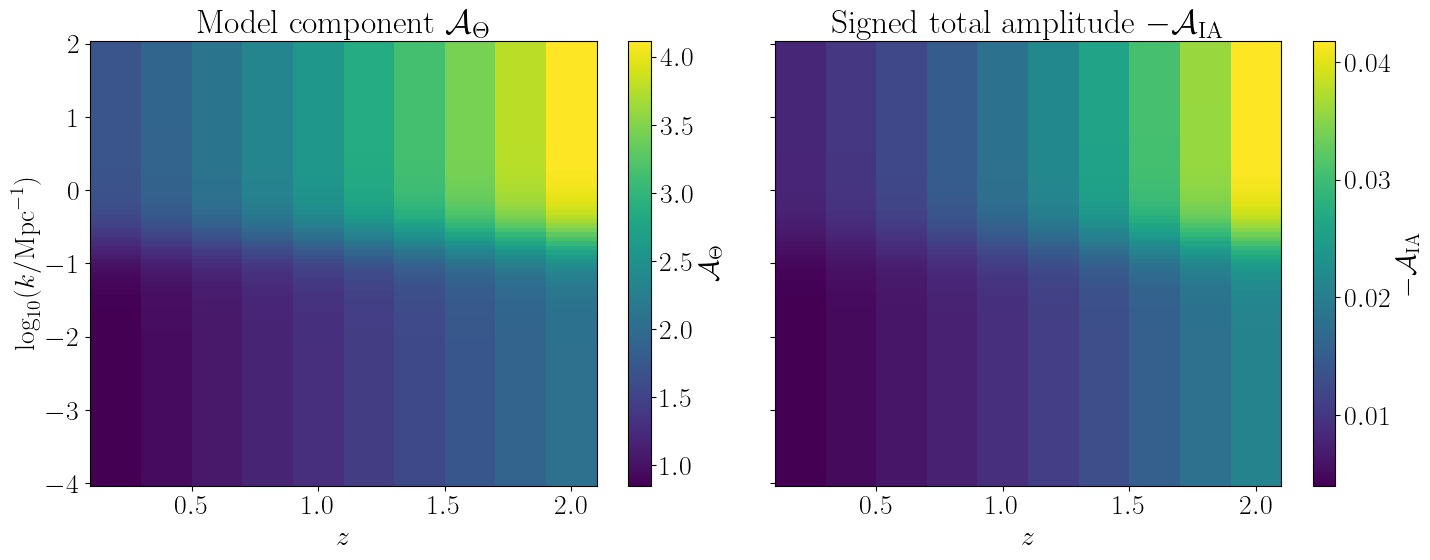

In [9]:
figure, axes = pyplot.subplots(1, 3, figsize=(19, 6), sharey=True)

surfaces = [S_k_z, A_theta, -A_IA]
titles = [
    r"Scale factor $S(k,z)$",
    r"Model component $\mathcal A_\Theta$",
    r"Signed total amplitude $-\mathcal A_{\rm IA}$",
]
labels = [r"$S(k,z)$", r"$\mathcal A_\Theta$", r"$-\mathcal A_{\rm IA}$"]

for axis, surface, title, label in zip(axes, surfaces, titles, labels):
    mesh = axis.pcolormesh(z, numpy.log10(k), surface.T, shading="auto")
    axis.set_xlabel(r"$z$")
    axis.set_title(title)
    figure.colorbar(mesh, ax=axis, label=label)

axes[0].set_ylabel(r"$\log_{10}(k/{\rm Mpc}^{-1})$")
figure.tight_layout()
pyplot.show()

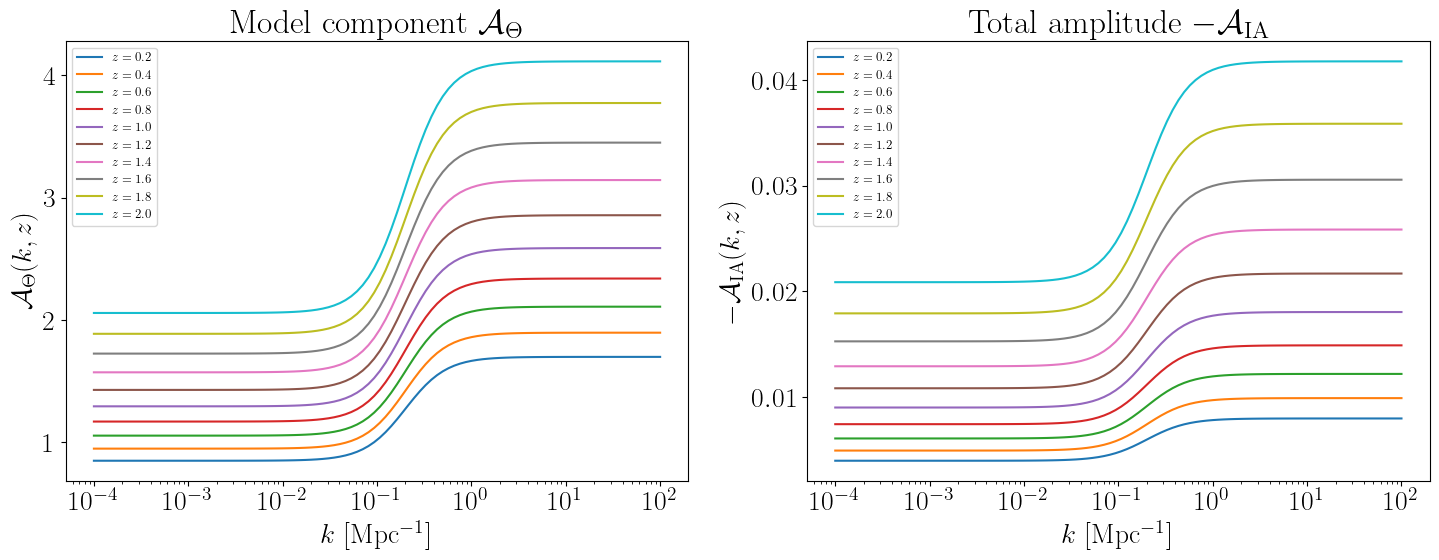

In [10]:
figure, axes = pyplot.subplots(1, 3, figsize=(19, 6))

for index, z_value in enumerate(z):
    label = rf"$z={z_value:.1f}$"
    axes[0].plot(k, S_k_z[index], label=label)
    axes[1].plot(k, A_theta[index], label=label)
    axes[2].plot(k, -A_IA[index], label=label)

titles = [r"$S(k,z)$", r"$\mathcal A_\Theta(k,z)$", r"$-\mathcal A_{\rm IA}(k,z)$"]
ylabels = [r"$S(k,z)$", r"$\mathcal A_\Theta(k,z)$", r"$-\mathcal A_{\rm IA}(k,z)$"]

for axis, title, ylabel in zip(axes, titles, ylabels):
    axis.set_xscale("log")
    axis.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.legend(fontsize=9)

figure.tight_layout()
pyplot.show()

---

## Apply the amplitude to the nonlinear matter spectrum

For NLA,

$$
\boxed{
P_{\delta I}(k,z)
=
\mathcal A_{\rm IA}(k,z)P_{\rm nl}(k,z)
}
$$

and

$$
\boxed{
P_{II}(k,z)
=
\mathcal A_{\rm IA}^2(k,z)P_{\rm nl}(k,z).
}
$$

The cross-spectrum retains the sign of $\mathcal A_{\rm IA}$, while the auto-spectrum
is non-negative.

In [11]:
P_m = numpy.vstack([
    pyccl.nonlin_matter_power(
        cosmology,
        k,
        1.0 / (1.0 + z_value),
    )
    for z_value in z
])

P_deltaI = A_IA * P_m
P_II = A_IA**2 * P_m

assert P_m.shape == A_IA.shape
assert numpy.allclose(P_deltaI / P_m, A_IA)
assert numpy.allclose(P_II / P_m, A_IA**2)
assert numpy.all(P_deltaI < 0.0)
assert numpy.all(P_II >= 0.0)

print("P_m shape:      ", P_m.shape)
print("P_deltaI shape: ", P_deltaI.shape)
print("P_II shape:     ", P_II.shape)

P_m shape:       (10, 100)
P_deltaI shape:  (10, 100)
P_II shape:      (10, 100)


### Inspect the resulting power spectra

A logarithmic axis cannot display a negative cross-spectrum, so the middle panel shows
$-P_{\delta I}$ and labels the sign explicitly. The signed values remain unchanged in
memory.

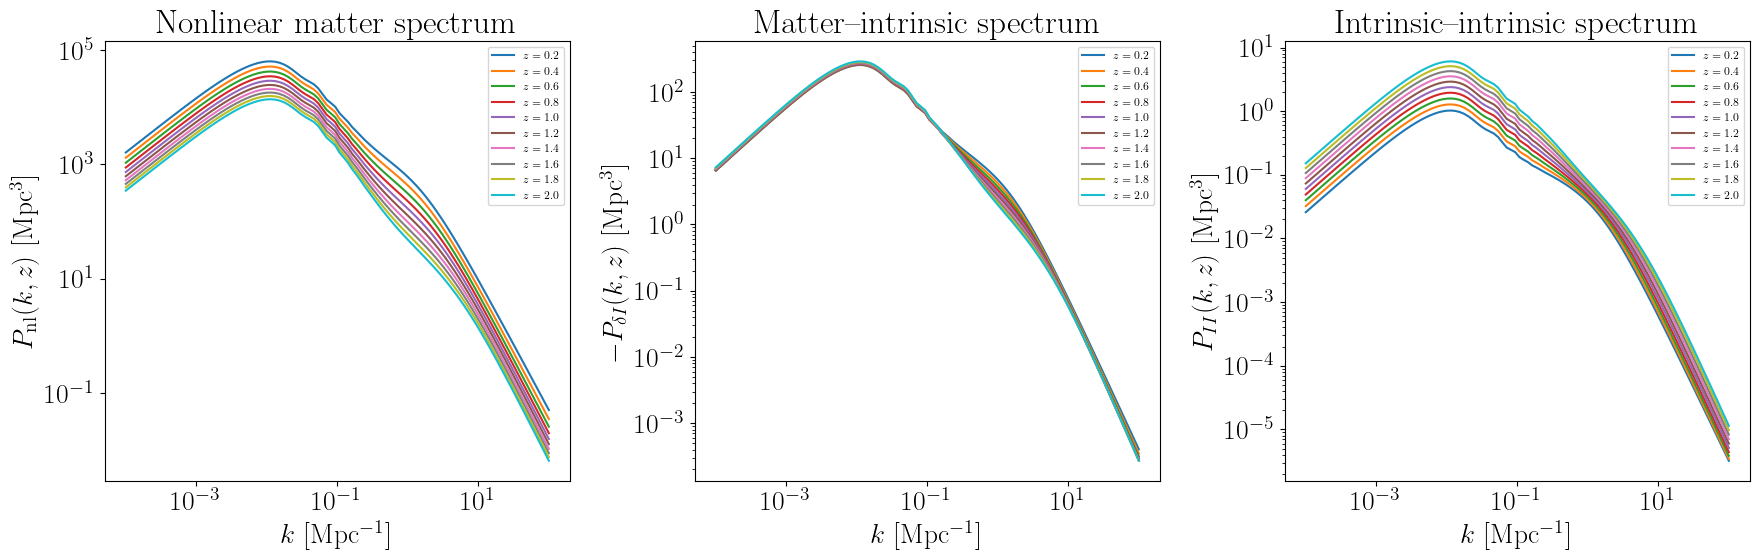

In [12]:
figure, axes = pyplot.subplots(1, 3, figsize=(18, 6))

for index, z_value in enumerate(z):
    label = rf"$z={z_value:.1f}$"
    axes[0].plot(k, P_m[index], label=label)
    axes[1].plot(k, -P_deltaI[index], label=label)
    axes[2].plot(k, P_II[index], label=label)

titles = [
    "Nonlinear matter spectrum",
    "Matter--intrinsic spectrum",
    "Intrinsic--intrinsic spectrum",
]
ylabels = [
    r"$P_{\rm nl}(k,z)$ [Mpc$^3$]",
    r"$-P_{\delta I}(k,z)$ [Mpc$^3$]",
    r"$P_{II}(k,z)$ [Mpc$^3$]",
]

for axis, title, ylabel in zip(axes, titles, ylabels):
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axis.set_ylabel(ylabel)
    axis.set_title(title)
    axis.legend(fontsize=8)

figure.tight_layout()
pyplot.show()

### Isolate the effect of the extended scale model

Compare the fiducial model with two controlled variants: scale-independent NLA
($q=0$), and the former plateau form ($\alpha=\gamma_t=\gamma_n=0$). Holding all
other parameters fixed makes changes in the spectra directly attributable to
$S(k,z)$.

In [ ]:
from dataclasses import replace

comparison_models = {
    "scale-independent": replace(fiducial_model, q=0.0),
    "constant plateau": replace(
        fiducial_model,
        alpha=0.0,
        gamma_t=0.0,
        gamma_n=0.0,
    ),
    "joint scale--redshift": fiducial_model,
}

comparison_redshift_index = -1
figure, axes = pyplot.subplots(1, 3, figsize=(19, 6))

for label, model in comparison_models.items():
    model_components = model.amplitude_components(cosmology, z, k)
    model_S_k_z = model.scale_dependence(z, k)
    model_P_deltaI = model_components["A_IA"] * P_m
    model_P_II = model_components["A_IA"]**2 * P_m

    axes[0].plot(k, model_S_k_z[comparison_redshift_index], label=label)
    axes[1].plot(k, -model_P_deltaI[comparison_redshift_index], label=label)
    axes[2].plot(k, model_P_II[comparison_redshift_index], label=label)

titles = [r"$S(k,z)$", r"$-P_{\delta I}(k,z)$", r"$P_{II}(k,z)$"]
ylabels = [r"$S(k,z)$", r"$-P_{\delta I}$ [Mpc$^3$]", r"$P_{II}$ [Mpc$^3$]"]

for axis, title, ylabel in zip(axes, titles, ylabels):
    axis.set_xscale("log")
    axis.set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axis.set_ylabel(ylabel)
    axis.set_title(title + rf" at $z={z[comparison_redshift_index]}$")
    axis.legend(fontsize=9)

axes[1].set_yscale("log")
axes[2].set_yscale("log")
figure.tight_layout()
pyplot.show()

---

## Choose the object to compress

The factorization creates three increasingly difficult ML problems:

### Shape-only model compression

Compress

$$
\mathcal A_\Theta(k,z\mid\boldsymbol\Theta).
$$

This isolates the model-dependent surface and removes both cosmology and the scalar
normalization.

### Complete nuisance compression at fixed cosmology

Compress

$$
\mathcal A_{\rm nuisance}
=
A_0\mathcal A_\Theta.
$$

This includes the overall nuisance amplitude but avoids sampling cosmology.

### Joint cosmology and nuisance compression

Compress

$$
\mathcal A_{\rm IA}
=
-\mathcal A_\Omega\mathcal A_{\rm nuisance}.
$$

This is the more demanding problem. A successful compressor must be checked for
preservation of cosmological sensitivity; joint sampling alone does not guarantee it.

### Lecture checkpoints

Before moving on, make sure you can explain:

- why $\mathcal A_\Omega$ has shape $(N_z,)$ while $S_k_z$ and
  $\mathcal A_\Theta$ have shape $(N_z,N_k)$;
- why $R_z=r_\ast^\eta$ remains an explicit factor even though it is simple;
- why a singleton axis is needed during recombination;
- how the scale-independent, constant-plateau, and joint scale--redshift models
  change $P_{\delta I}$ and $P_{II}$;
- why factorized storage is useful for checking an ML compression.

---

## Continue to parameter sampling

`SAMPLE.ipynb` first provides a complete nuisance-only sampling example at fixed
cosmology. Its student assignment then extends the same factorized construction to a
joint cosmology-and-nuisance dataset.